## 1) Load Data

Load data, filter by removing unnecessary columns(data), and process the rest of it

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re

In [2]:
# Reset to default white theme and explicitly set face colors instead of using system theme colors
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'

In [3]:
pwd

'/home/yuchen/deeplab-insect-locomotion-analysis'

In [47]:
# FILE_DIR = str(Path('path')) # Replace 'path' with the actual path to your directory

FILES_DIR = [str(path) for path in Path('videos').glob('IMG_*_*seconds_*_filtered.csv')]
FILES_DIR.sort()

In [48]:
FILES_DIR

['videos/IMG_6866_01seconds_retractorDLC_Resnet50_Stick_Insect_Motion_Hacking_2D_TrackingSep10shuffle8_snapshot_640_filtered.csv',
 'videos/IMG_6867_1seconds_retractorDLC_Resnet50_Stick_Insect_Motion_Hacking_2D_TrackingSep10shuffle8_snapshot_640_filtered.csv',
 'videos/IMG_6869_2seconds_retractorDLC_Resnet50_Stick_Insect_Motion_Hacking_2D_TrackingSep10shuffle8_snapshot_640_filtered.csv',
 'videos/IMG_6871_3seconds_retractorDLC_Resnet50_Stick_Insect_Motion_Hacking_2D_TrackingSep10shuffle8_snapshot_640_filtered.csv',
 'videos/IMG_6945_01seconds_protractorDLC_Resnet50_Stick_Insect_Motion_Hacking_2D_TrackingSep10shuffle8_snapshot_640_filtered.csv',
 'videos/IMG_6946_05seconds_protractorDLC_Resnet50_Stick_Insect_Motion_Hacking_2D_TrackingSep10shuffle8_snapshot_640_filtered.csv',
 'videos/IMG_6947_1seconds_protractorDLC_Resnet50_Stick_Insect_Motion_Hacking_2D_TrackingSep10shuffle8_snapshot_640_filtered.csv',
 'videos/IMG_6948_2seconds_protractorDLC_Resnet50_Stick_Insect_Motion_Hacking_2D_Tra

In [ ]:
df = pd.read_csv(FILE_DIR)

In [49]:
# Loading multiple dataframes from multiple files
df_array = []
for file in FILES_DIR:
    df_array.append(pd.read_csv(file))

In [ ]:
bodyparts= df.iloc[0,1:]
coords = df.iloc[1,1:]

df_filtered = df.iloc[2:].reset_index(drop=True) # remove the first two rows which are not needed

flat_cols = ['frame'] + [
    f'{bp}_{c}' for bp, c in zip(bodyparts, coords)
]

df_filtered.columns = flat_cols
df_filtered = df_filtered.astype({col: float for col in df_filtered.columns if col != 'frame'})
df_filtered.drop(list(df_filtered.filter(regex='likelihood')), axis=1, inplace=True)

In [50]:
df_filtered_array = []

for df in df_array:
    bodyparts= df.iloc[0,1:]
    coords = df.iloc[1,1:]

    df_filtered = df.iloc[2:].reset_index(drop=True) # remove the first two rows which are not needed

    flat_cols = ['frame'] + [
        f'{bp}_{c}' for bp, c in zip(bodyparts, coords)
    ]

    df_filtered.columns = flat_cols
    df_filtered = df_filtered.astype({col: float for col in df_filtered.columns if col != 'frame'})
    df_filtered.drop(list(df_filtered.filter(regex='likelihood')), axis=1, inplace=True)

    df_filtered_array.append(df_filtered)

In [19]:
df_filtered_array

[     frame  TC_Front_Leg_x  TC_Front_Leg_y  TC_Middle_Leg_x  TC_Middle_Leg_y  \
 0        0       1405.9695       1224.8533        1818.7617        1175.7828   
 1        1       1406.1051       1225.0236        1818.8588        1175.8169   
 2        2       1406.2585       1225.1543        1818.8601        1175.8195   
 3        3       1406.2585       1225.1543        1818.8616        1175.8242   
 4        4       1406.2585       1225.1543        1819.0591        1175.8536   
 ...    ...             ...             ...              ...              ...   
 1221  1221       1403.0167       1220.9458        1816.3850        1172.1229   
 1222  1222       1403.0167       1220.9554        1816.3850        1172.1278   
 1223  1223       1403.0973       1220.9554        1816.3850        1172.1229   
 1224  1224       1403.0973       1220.9554        1816.3706        1172.0953   
 1225  1225       1402.6799       1220.7225        1815.9115        1171.9410   
 
       FT_Middle_leg_x  FT

In [ ]:
df_filtered['TCTC_vector_x'] = df_filtered['TC_Middle_Leg_x'] - df_filtered['TC_Front_Leg_x'] 
df_filtered['TCTC_vector_y'] = df_filtered['TC_Middle_Leg_y'] - df_filtered['TC_Front_Leg_y']

df_filtered['TCFT_vector_x'] = df_filtered['TC_Middle_Leg_x'] - df_filtered['FT_Middle_Leg_x']
df_filtered['TCFT_vector_y'] = df_filtered['TC_Middle_Leg_y'] - df_filtered['FT_Middle_Leg_y']

# Dot product and magnitudes of the two vectors to get the cosine of the angle between them
df_filtered['dot_product'] = df_filtered['TCTC_vector_x'] * df_filtered['TCFT_vector_x'] + df_filtered['TCTC_vector_y'] * df_filtered['TCFT_vector_y']

df_filtered['TCTC_magnitude'] = (df_filtered['TCTC_vector_x']**2 + df_filtered['TCTC_vector_y']**2)**0.5
df_filtered['TCFT_magnitude'] = (df_filtered['TCFT_vector_x']**2 + df_filtered['TCFT_vector_y']**2)**0.5


df_filtered['cosine_angle'] = (df_filtered['dot_product'] / (df_filtered['TCTC_magnitude'] * df_filtered['TCFT_magnitude'])).clip(-1.0, 1.0)
df_filtered['angle'] = np.arccos(df_filtered['cosine_angle']) * 180 / np.pi

In [51]:
for df_filtered in df_filtered_array:
    
    df_filtered['TCTC_vector_x'] = df_filtered['TC_Middle_Leg_x'] - df_filtered['TC_Front_Leg_x'] 
    df_filtered['TCTC_vector_y'] = df_filtered['TC_Middle_Leg_y'] - df_filtered['TC_Front_Leg_y']

    df_filtered['TCFT_vector_x'] = df_filtered['TC_Middle_Leg_x'] - df_filtered['FT_Middle_leg_x']
    df_filtered['TCFT_vector_y'] = df_filtered['TC_Middle_Leg_y'] - df_filtered['FT_Middle_leg_y']

    # Dot product and magnitudes of the two vectors to get the cosine of the angle between them
    df_filtered['dot_product'] = df_filtered['TCTC_vector_x'] * df_filtered['TCFT_vector_x'] + df_filtered['TCTC_vector_y'] * df_filtered['TCFT_vector_y']

    df_filtered['TCTC_magnitude'] = (df_filtered['TCTC_vector_x']**2 + df_filtered['TCTC_vector_y']**2)**0.5
    df_filtered['TCFT_magnitude'] = (df_filtered['TCFT_vector_x']**2 + df_filtered['TCFT_vector_y']**2)**0.5


    df_filtered['cosine_angle'] = (df_filtered['dot_product'] / (df_filtered['TCTC_magnitude'] * df_filtered['TCFT_magnitude'])).clip(-1.0, 1.0)
    df_filtered['angle'] = np.arccos(df_filtered['cosine_angle']) * 180 / np.pi

    

In [ ]:
df_filtered['angle'].plot(title='Angle between TCTC and TCFT vectors over time', xlabel='Frame', ylabel='Angle (degrees)')

In [120]:
def clean_filename(text):
    # Matches optional 'I', 'MG', numbers, seconds, and the name
    match = re.match(r"^I?MG_\d+_(\d+)(seconds)_([a-zA-Z]+)", text)
    
    if match:
        num, time_suffix, name = match.groups()
        
        # Convert "01" to "0.1", otherwise keep as is (e.g., "3")
        if len(num) == 2 and num.startswith('0'):
            num = f"0.{num[1]}"
            
        # Format strings
        # formatted_time = f"{num} {time_suffix.capitalize()}" # Uses more descipritve name e.g. '1 seconds Retractor'
        formatted_time = f"${num}\,s$" # uses more compact naming '1s Retractor'
        formatted_name = name.capitalize()
        
        return f"{formatted_time} {formatted_name}"
    return text

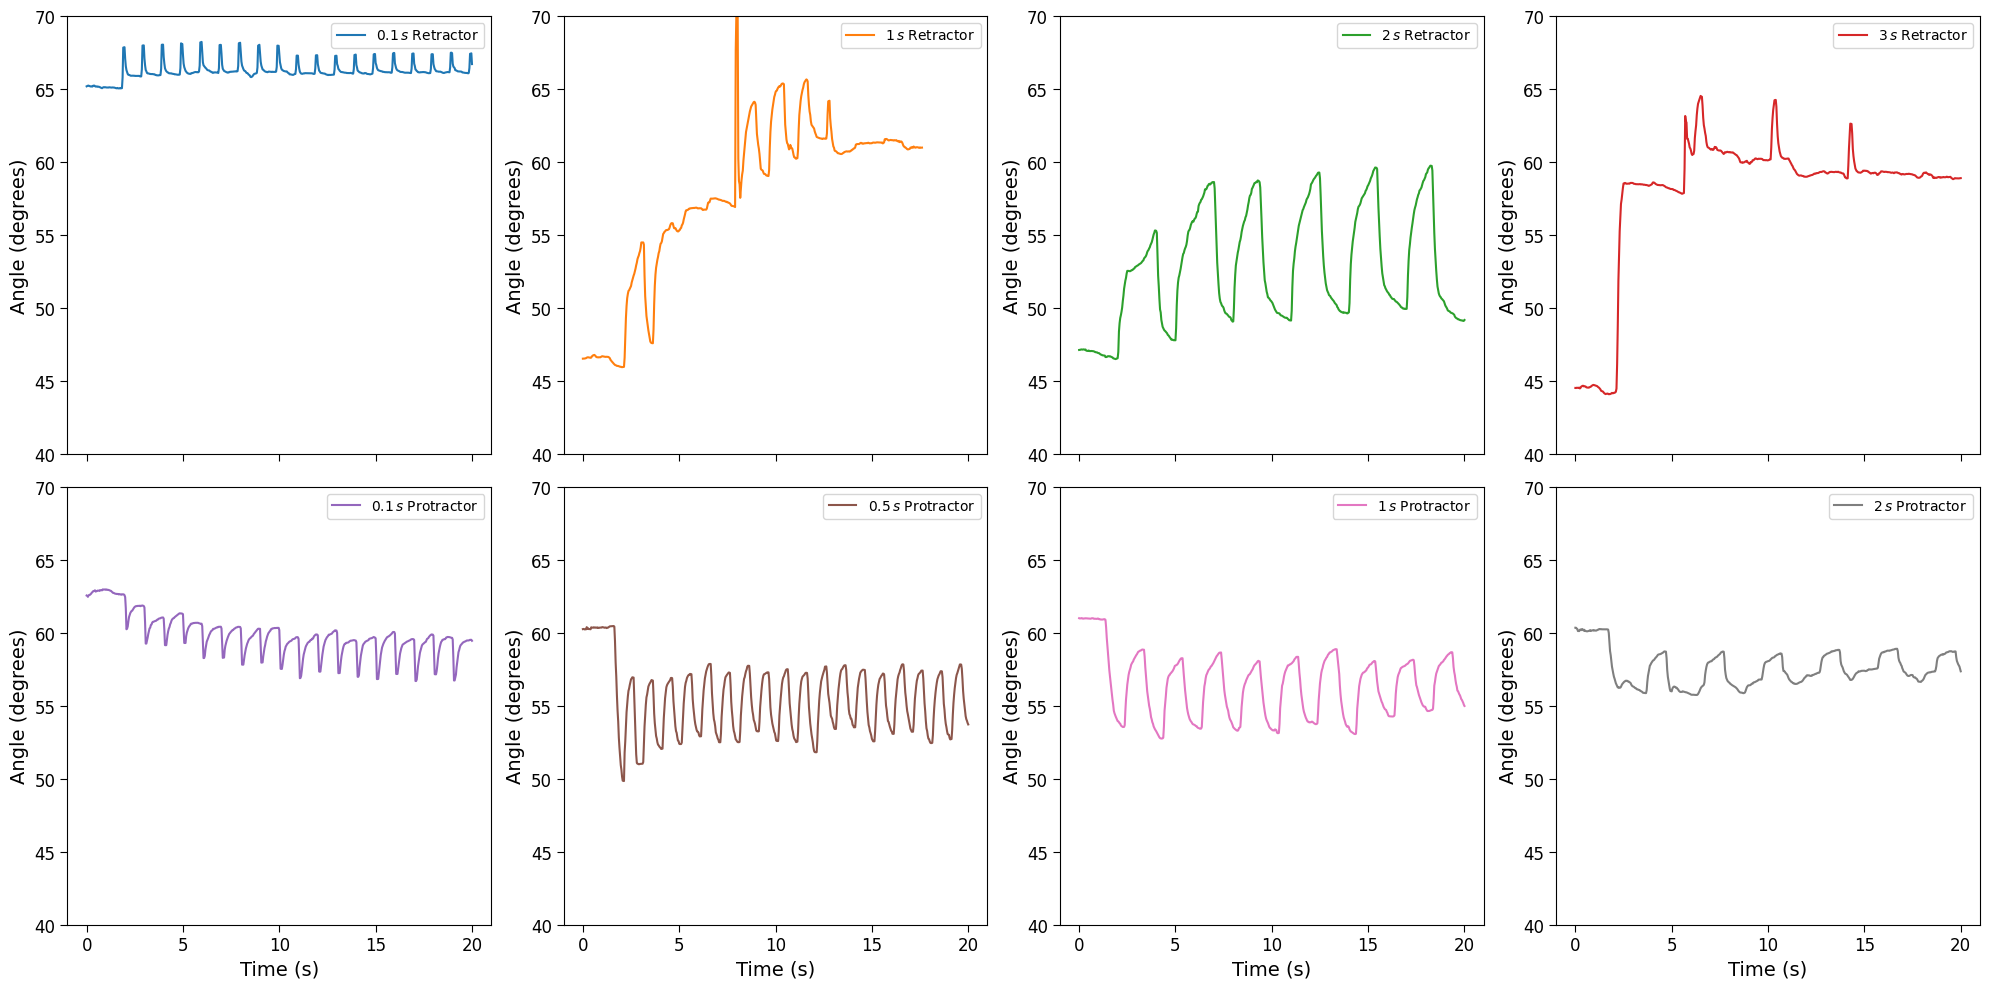

In [122]:
# Create new dataframe that combines all dataframes' angle column into one
angle_df = pd.DataFrame()

for i, (file_path, df) in enumerate(zip(FILES_DIR, df_filtered_array)):
    clean_label = Path(file_path).name.split('DLC')[0]
    formatted_label = clean_filename(clean_label)
    
    # Add the angle data for this video
    angle_df[formatted_label] = df['angle']

    # Only create the time column ONCE using the first dataframe
    if i == 0:
        angle_df['time'] = pd.to_numeric(df['frame'], errors='coerce') / 30

# Set 'time' as the index so pandas automatically uses it for the x-axis
angle_df.set_index('time', inplace=True)
angle_df_20s = angle_df[angle_df.index <= 20]

axes = angle_df_20s.plot(
    # title='Angle between TCTC and TCFT vectors over time', 
    xlabel='Time (s)', 
    ylabel='Angle (degrees)', 
    subplots=True, 
    layout=(2, 4), 
    figsize=(20, 10)
)

# Set a y axis limit so the data can be compared just by eyes
for ax in axes.flatten():
    ax.set_ylim(40, 70)
    ax.tick_params(axis='both', which='major', labelsize=12, length=5)
    ax.xaxis.label.set_fontsize(14)
    ax.yaxis.label.set_fontsize(14)
plt.tight_layout()
plt.savefig('/home/yuchen/Downloads/time_series_angles.png', format='png', bbox_inches='tight')
plt.show()

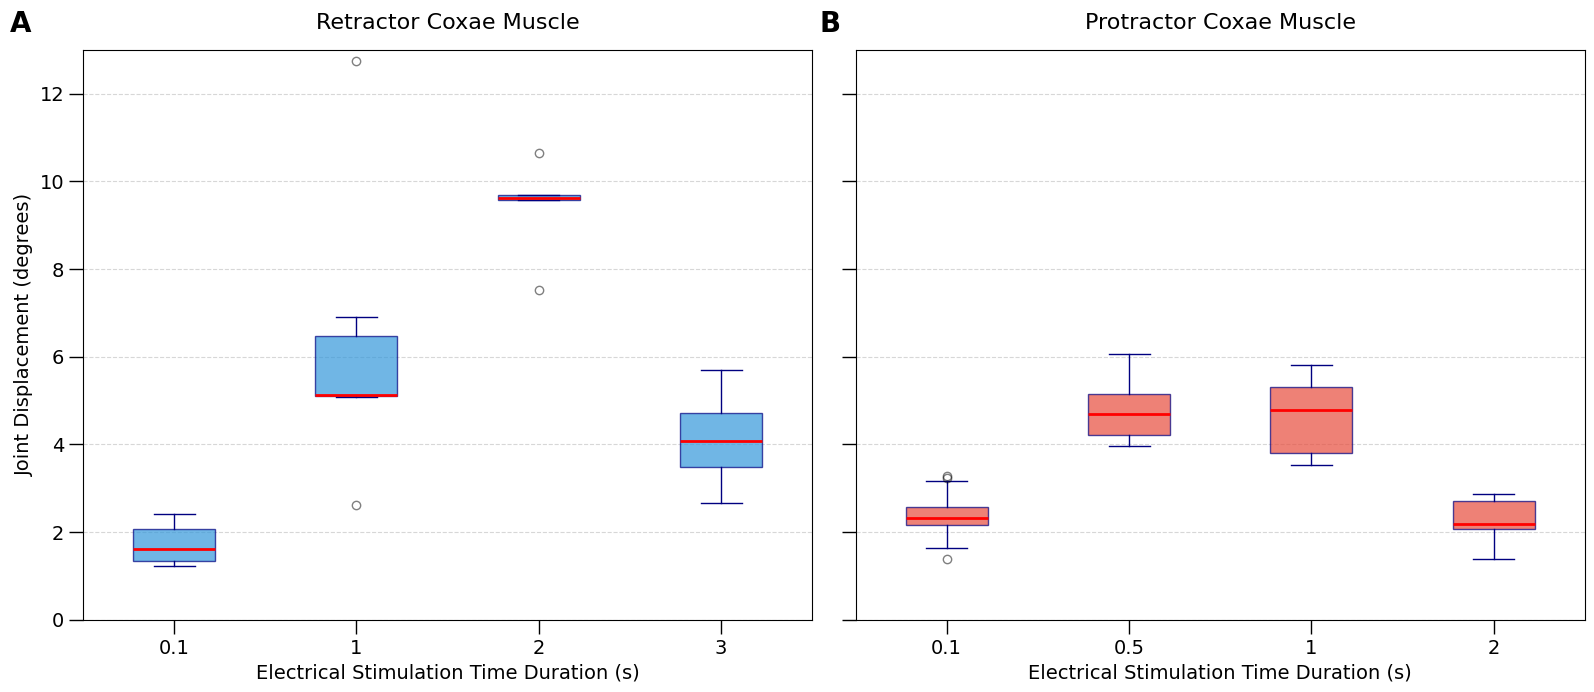

In [ ]:
from scipy.signal import find_peaks

# Collect peak differences for each column
retractor_diffs = []
protractor_diffs = []
retractor_labels = []
protractor_labels = []


# Collect peak differences and labels for each group
for i, col in enumerate(angle_df_20s.columns):
    signal = angle_df_20s[col].dropna().values
    peaks, properties = find_peaks(signal, prominence=1)
    peak_differences = properties['prominences']
    
    # Extract the label using regex
    label = ''.join(re.findall(r'\d+\.?\d*', col))
    
    if i < 4:
        retractor_diffs.append(peak_differences)
        retractor_labels.append(label)
    else:
        protractor_diffs.append(peak_differences)
        protractor_labels.append(label)

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharey=True)


# Plot retractor joint displacements
ax1.boxplot(
    retractor_diffs,
    patch_artist=True,
    boxprops=dict(facecolor='#3498db', color='navy', alpha=0.7), # Soft Blue
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(color='navy'),
    capprops=dict(color='navy'),
    flierprops=dict(marker='o', color='gray', alpha=0.5)
)

ax1.text(-0.1, 1.07, 'A', transform=ax1.transAxes, fontsize=20, fontweight='bold', va='top')
ax1.set_title('Retractor Coxae Muscle', fontsize=16, pad=15)
ax1.set_xticklabels(retractor_labels)
ax1.set_xlabel('Electrical Stimulation Time Duration (s)', fontsize=14)
ax1.set_ylabel('Joint Displacement (degrees)', fontsize=14)
ax1.set_ylim(0, 13)
ax1.grid(True, linestyle='--', alpha=0.5, axis='y')
ax1.tick_params(axis='both', which='major', labelsize=14, length=10, width=1)

# Plot protractor joint displacements
ax2.boxplot(
    protractor_diffs,
    patch_artist=True,
    boxprops=dict(facecolor='#e74c3c', color='navy', alpha=0.7), # Soft Red
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(color='navy'),
    capprops=dict(color='navy'),
    flierprops=dict(marker='o', color='gray', alpha=0.5)
)
ax2.text(-0.05, 1.07, 'B', transform=ax2.transAxes, fontsize=20, fontweight='bold', va='top')
ax2.set_title('Protractor Coxae Muscle', fontsize=16, pad=15)
ax2.set_xticklabels(protractor_labels)
ax2.set_xlabel('Electrical Stimulation Time Duration (s)', fontsize=14)
# Y-label is omitted here to keep it clean, as sharey=True links it with Plot 1
ax2.set_ylim(0, 13)
ax2.grid(True, linestyle='--', alpha=0.5, axis='y')
ax2.tick_params(axis='both', which='major', labelsize=14, length=10, width=1)


# Plot vizualization and saving
plt.tight_layout()
plt.savefig(desired_path, format='png', bbox_inches='tight')
plt.show()